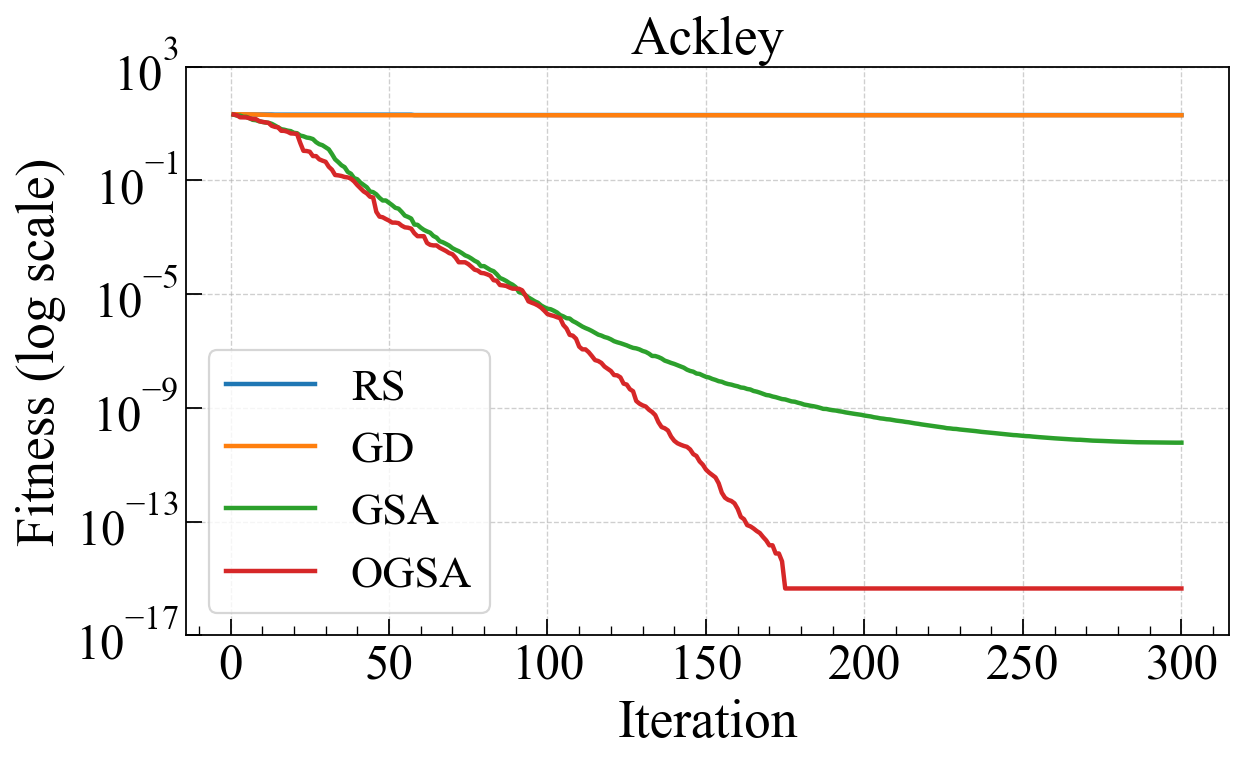

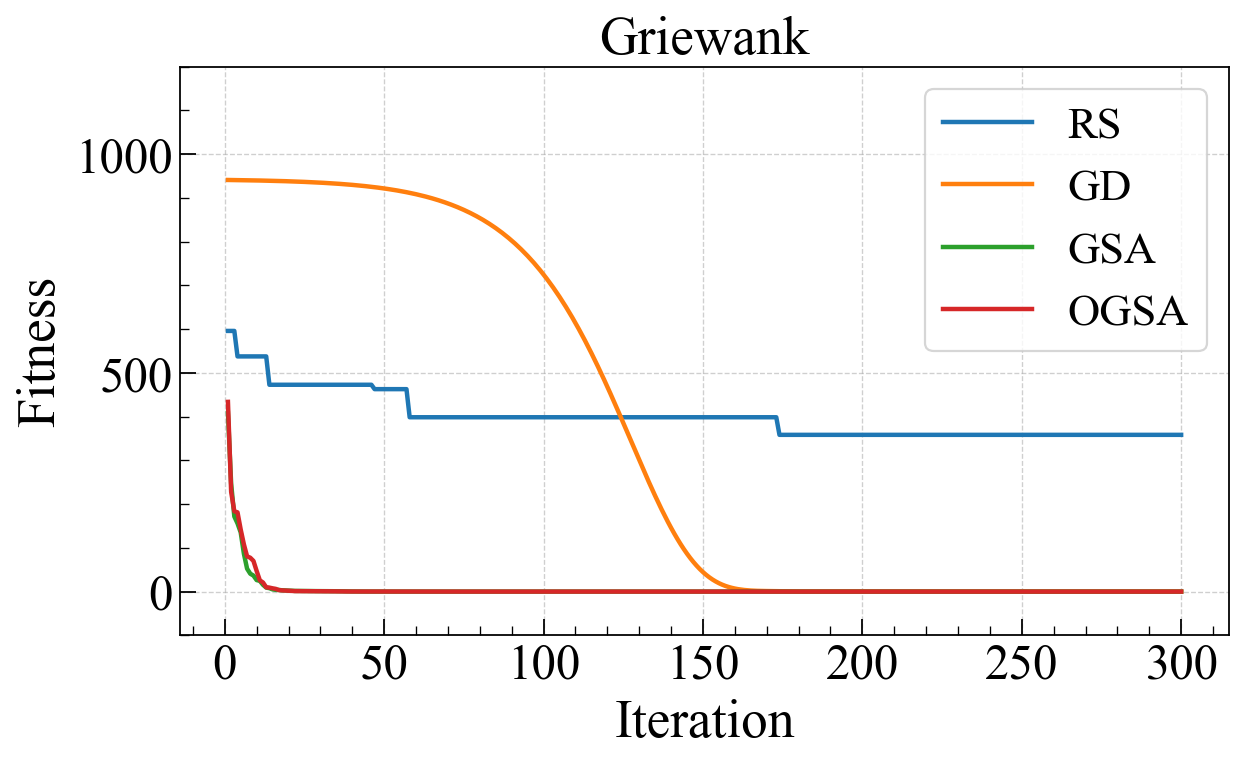

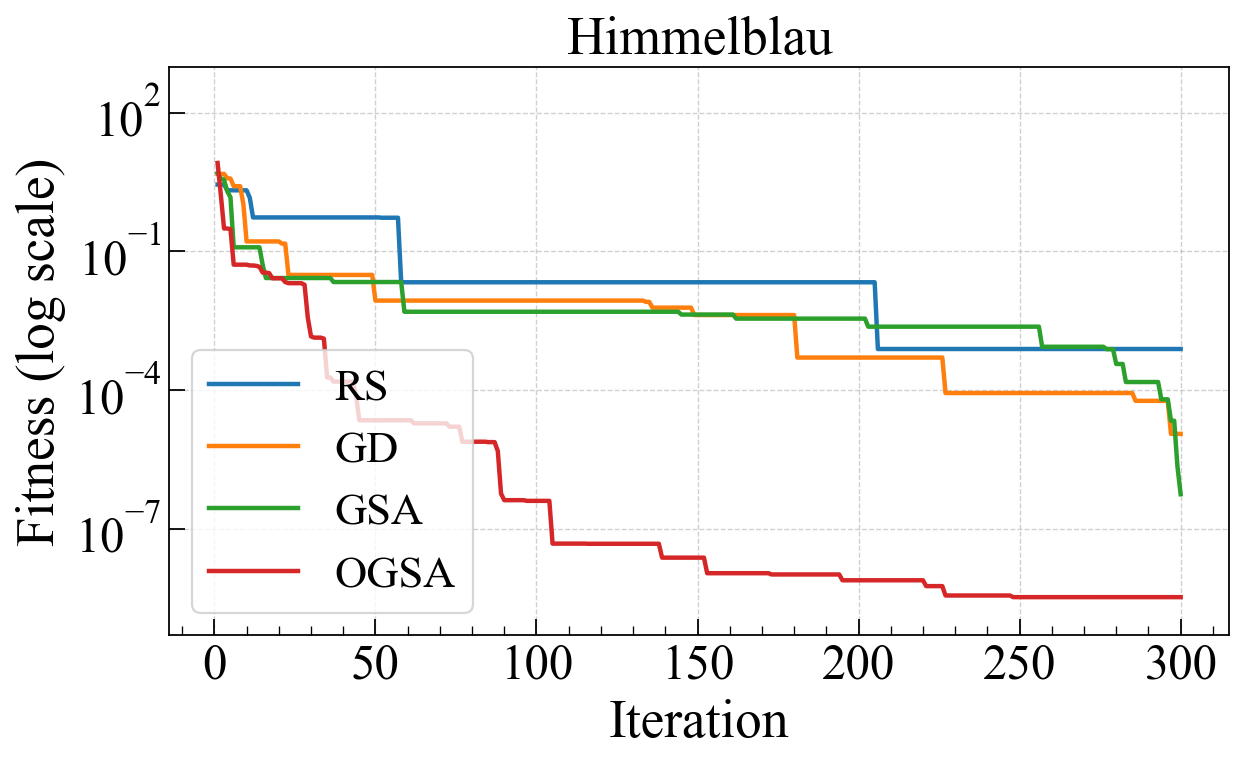

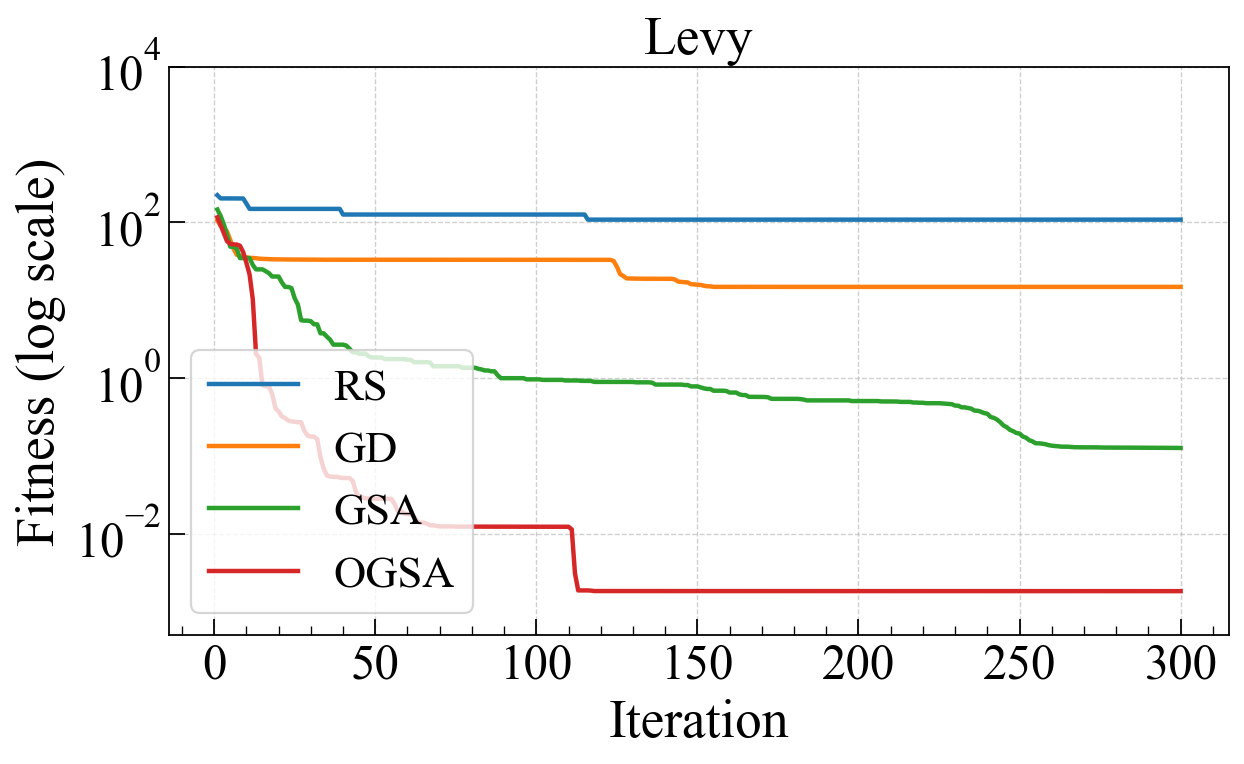

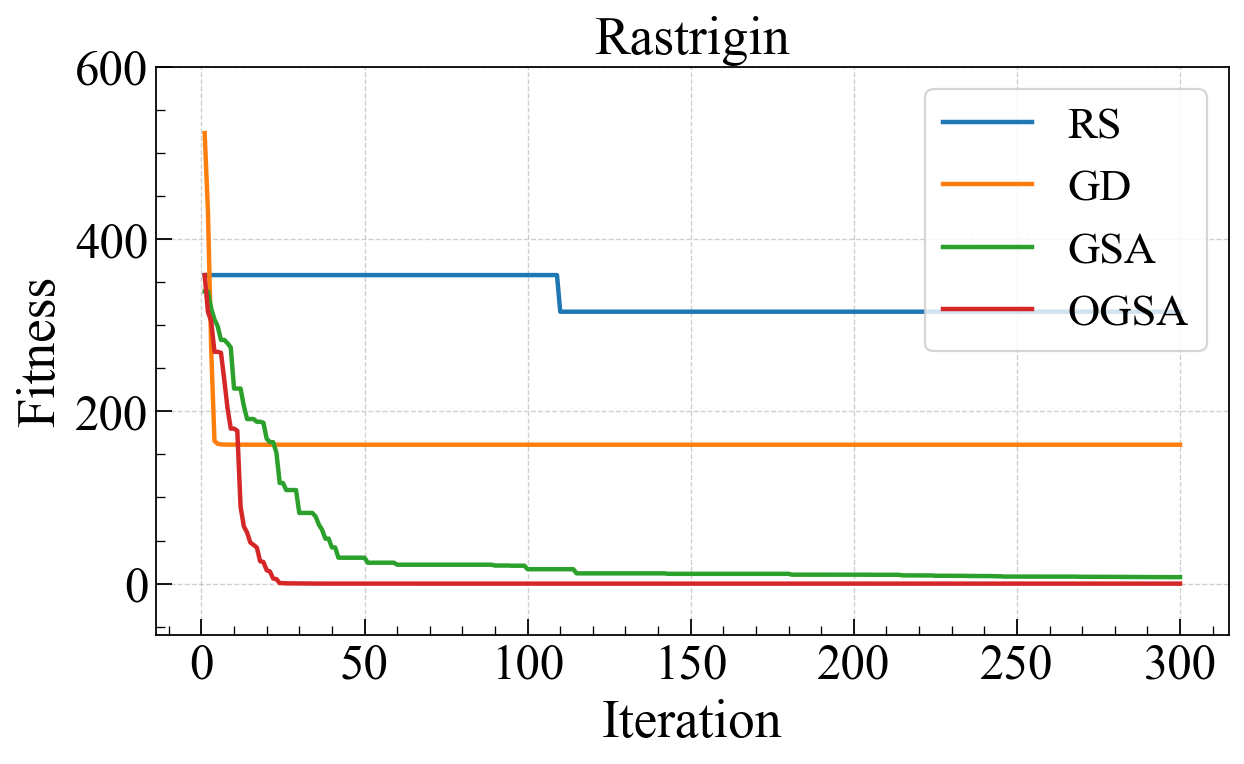

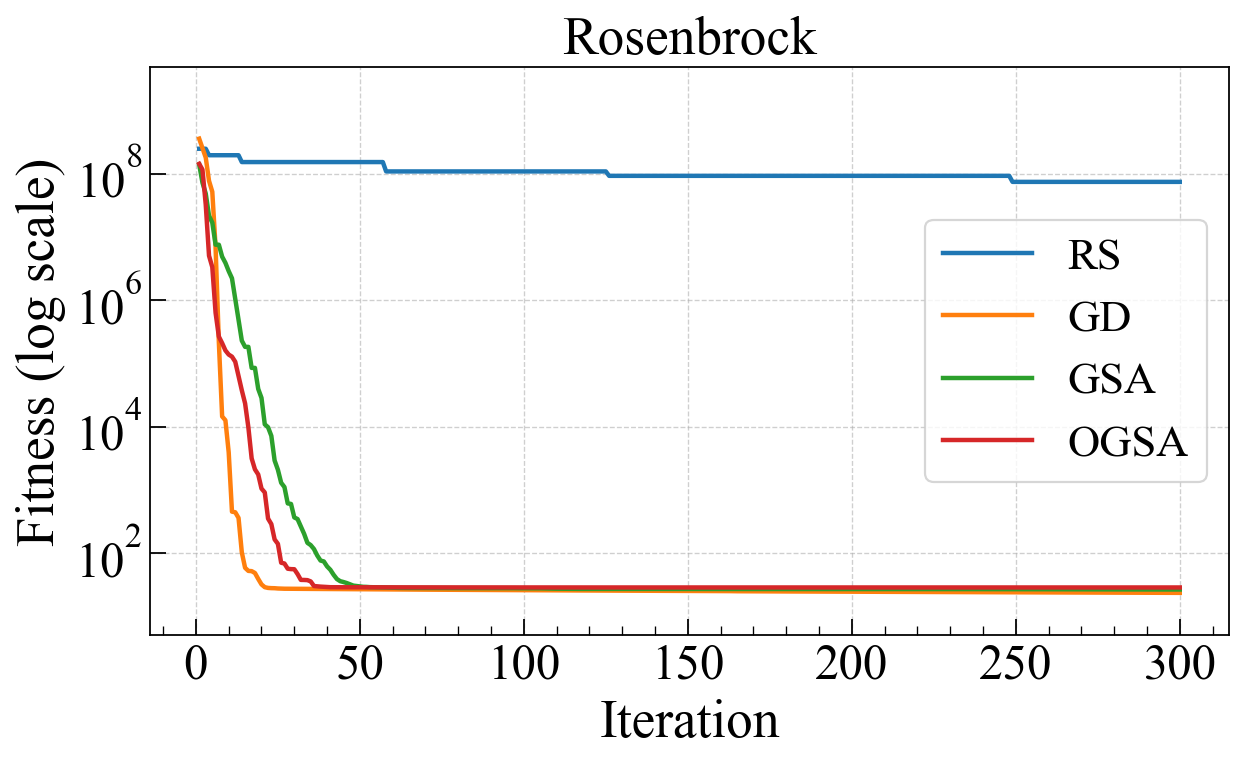

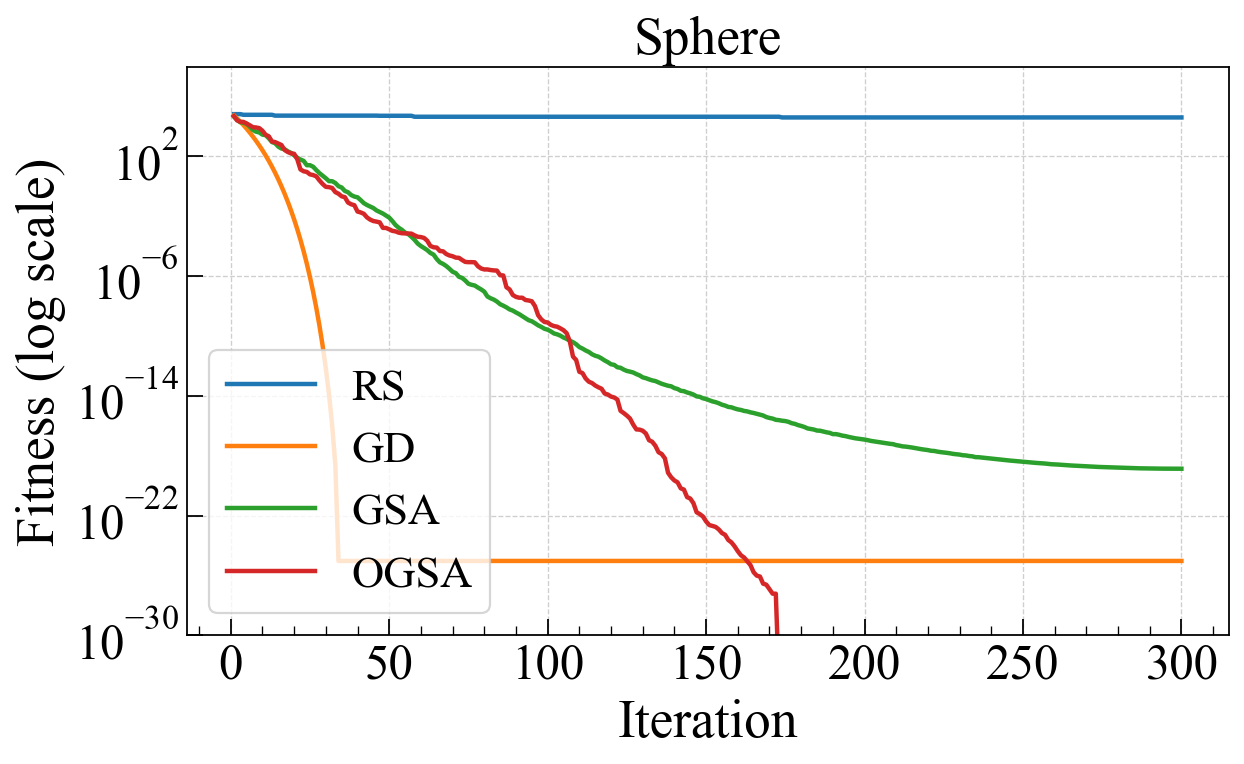

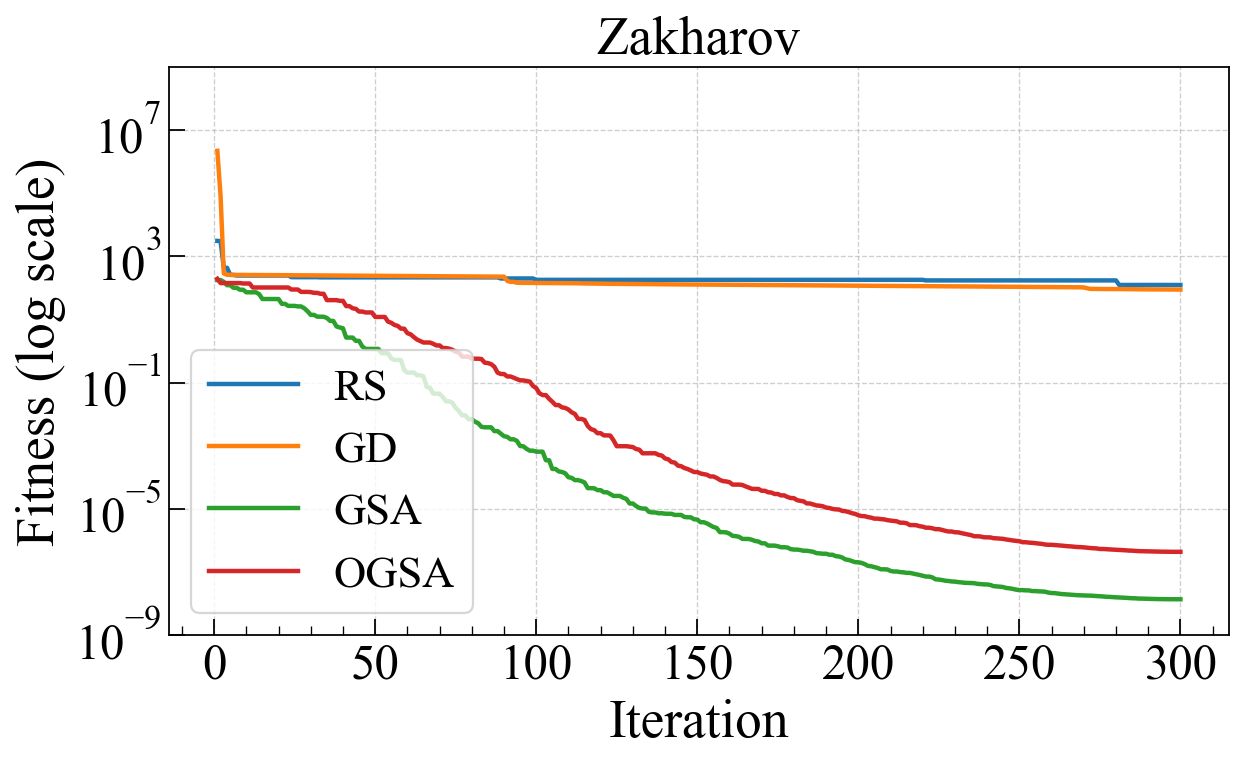

In [9]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_PATH = "Benchmark Data.xlsx"
OUT_DIR = "plots"
ALGO_ORDER = ["RS", "GD", "GSA", "OGSA"]

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20,
    "figure.titlesize": 24,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
})
LINEWIDTH = 2

LOG_POLICY_GLOBAL = "auto"
LOG_POLICY_PER_FUNC = {}
YLIM_GLOBAL = None
YLIM_PER_FUNC = {}
AUTO_Y_MARGIN_RATIO = 0.05

def _norm(s):
    return re.sub(r"[\s_\-]+", "", str(s)).lower()

def _clean_sheet_name(name):
    n = str(name).strip()
    n = re.sub(r"\s*[_\-]?\s*sheet\s*\d+$", "", n, flags=re.IGNORECASE)
    n = re.sub(r"\s*[_\-]?\s*summary$", "", n, flags=re.IGNORECASE)
    n = re.sub(r"\s*[_\-]?\s*benchmark$", "", n, flags=re.IGNORECASE)
    return n or str(name)

def _looks_summary(df):
    lowered = {_norm(c) for c in df.columns}
    return {"algorithm", "bestoverall", "average", "std"}.issubset(lowered)

def _find_iteration_col(df):
    if df.shape[1] == 0:
        return None
    for c in df.columns:
        if _norm(c) == "iteration":
            return c
    for c in df.columns:
        if _norm(c).startswith("iter"):
            return c
    c0 = df.columns[0]
    vals = pd.to_numeric(df[c0], errors="coerce")
    if vals.notna().sum() >= max(5, len(df)//5) and np.all(np.diff(vals.dropna().values) >= 0):
        return c0
    return None

def _find_algo_cols(df):
    colmap = {_norm(c): c for c in df.columns}
    found = {}
    for algo in ALGO_ORDER:
        key = algo.lower()
        if key in colmap:
            found[algo] = colmap[key]
            continue
        for k, orig in colmap.items():
            if k.startswith(key):
                found[algo] = orig
                break
    return found

def _auto_log_decision(series_list):
    all_vals = pd.concat([s.dropna() for s in series_list], axis=0) if series_list else pd.Series(dtype=float)
    if all_vals.empty:
        return "linear", None
    pos_vals = all_vals[all_vals > 0]
    non_nan_cnt = int(all_vals.shape[0])
    pos_ratio = float(pos_vals.shape[0]) / max(1, non_nan_cnt)
    if pos_vals.shape[0] > 0:
        min_pos = float(pos_vals.min())
        max_pos = float(pos_vals.max())
        dynamic = (max_pos / min_pos) if min_pos > 0 else np.inf
    else:
        min_pos, dynamic = None, 0.0
    if pos_ratio >= 0.9 and dynamic >= 1e4:
        return "log", min_pos
    return "linear", None

def _decide_log_mode(func_name, curves):
    mode = LOG_POLICY_PER_FUNC.get(func_name, None)
    if mode in ("force_log", "force_linear"):
        if mode == "force_log":
            all_vals = pd.concat([v.dropna() for v in curves.values()], axis=0) if curves else pd.Series(dtype=float)
            pos_vals = all_vals[all_vals > 0]
            min_pos = float(pos_vals.min()) if not pos_vals.empty else 1e-12
            return "log", min_pos
        return "linear", None
    if LOG_POLICY_GLOBAL == "force_log":
        all_vals = pd.concat([v.dropna() for v in curves.values()], axis=0) if curves else pd.Series(dtype=float)
        pos_vals = all_vals[all_vals > 0]
        min_pos = float(pos_vals.min()) if not pos_vals.empty else 1e-12
        return "log", min_pos
    if LOG_POLICY_GLOBAL == "force_linear":
        return "linear", None
    return _auto_log_decision(list(curves.values()))

def _decide_ylim(func_name, use_log, curves):
    yl = YLIM_PER_FUNC.get(func_name, None)
    if yl is not None:
        return yl
    if YLIM_GLOBAL is not None:
        return YLIM_GLOBAL
    if not use_log:
        all_vals = pd.concat([v.dropna() for v in curves.values()], axis=0) if curves else pd.Series(dtype=float)
        if all_vals.empty:
            return None
        ymin = float(all_vals.min())
        ymax = float(all_vals.max())
        if ymin == ymax:
            return (ymin - 1.0, ymax + 1.0)
        pad = (ymax - ymin) * AUTO_Y_MARGIN_RATIO
        return (ymin - pad, ymax + pad)
    return None

def main():
    assert os.path.exists(EXCEL_PATH), f"找不到 Excel 文件：{EXCEL_PATH}"
    xls = pd.ExcelFile(EXCEL_PATH)
    skipped = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet)
        df = df.dropna(axis=1, how="all")
        if df.empty or _looks_summary(df):
            skipped.append(sheet)
            continue

        func = _clean_sheet_name(sheet)
        if func in {"Beale", "Schwefel"}:
            continue

        iter_col = _find_iteration_col(df)
        algo_cols = _find_algo_cols(df)
        if not algo_cols:
            skipped.append(sheet)
            continue

        if iter_col is not None:
            x = pd.to_numeric(df[iter_col], errors="coerce").reset_index(drop=True)
        else:
            x = pd.Series(np.arange(1, len(df) + 1), name="Iteration")

        curves = {}
        for algo in ALGO_ORDER:
            col = algo_cols.get(algo)
            if col is None:
                continue
            curves[algo] = pd.to_numeric(df[col], errors="coerce").reset_index(drop=True)
        if not curves:
            skipped.append(sheet)
            continue

        log_mode, min_pos = _decide_log_mode(func, curves)
        use_log = (log_mode == "log")

        if use_log:
            eps_base = (min_pos if (min_pos is not None and min_pos > 0) else 1e-12)
            eps = max(eps_base * 1e-6, 1e-300)
            for k in list(curves.keys()):
                y = curves[k].copy()
                y = y.mask(y <= 0, eps)
                curves[k] = y

        ylim = _decide_ylim(func, use_log, curves)

        fig, ax = plt.subplots(figsize=(8, 5), dpi=160)
        for algo in ALGO_ORDER:
            if algo not in curves:
                continue
            y = curves[algo]
            n = min(len(x), len(y))
            ax.plot(x.iloc[:n], y.iloc[:n], label=algo, linewidth=LINEWIDTH)

        ax.set_xlabel("Iteration")
        ax.set_ylabel("Fitness" + (" (log scale)" if use_log else ""))
        ax.set_title(f"{func}")
        if use_log:
            ax.set_yscale("log")
        if isinstance(ylim, tuple) and len(ylim) == 2:
            ymin, ymax = ylim
            if use_log and (ymin is not None) and ymin <= 0:
                ymin = 1e-300
            ax.set_ylim(ymin, ymax)

        ax.minorticks_on()
        ax.tick_params(axis="both", which="major", direction="in", top=False, right=False, length=7)
        ax.tick_params(axis="both", which="minor", direction="in", top=False, right=False, length=4)

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.legend()
        fig.tight_layout()
        plt.show()

YLIM_PER_FUNC.update({
    "Ackley": (1e-17, 1e3),
    "Beale": (5e-13, 1000.0),
    "Griewank": (-100, 1200.0),
    "Himmelblau": (5e-10, 1000.0),
    "Levy": (5e-4, 10000.0),
    "Rastrigin": (-60, 600.0),
    "Rosenbrock": (5, 5e9),
    "Sphere": (1e-30, 1e8),
    "Zakharov": (1e-9, 1e9),
})

LOG_POLICY_PER_FUNC.update({
    "Sphere": "force_log",
})

if __name__ == "__main__":
    main()

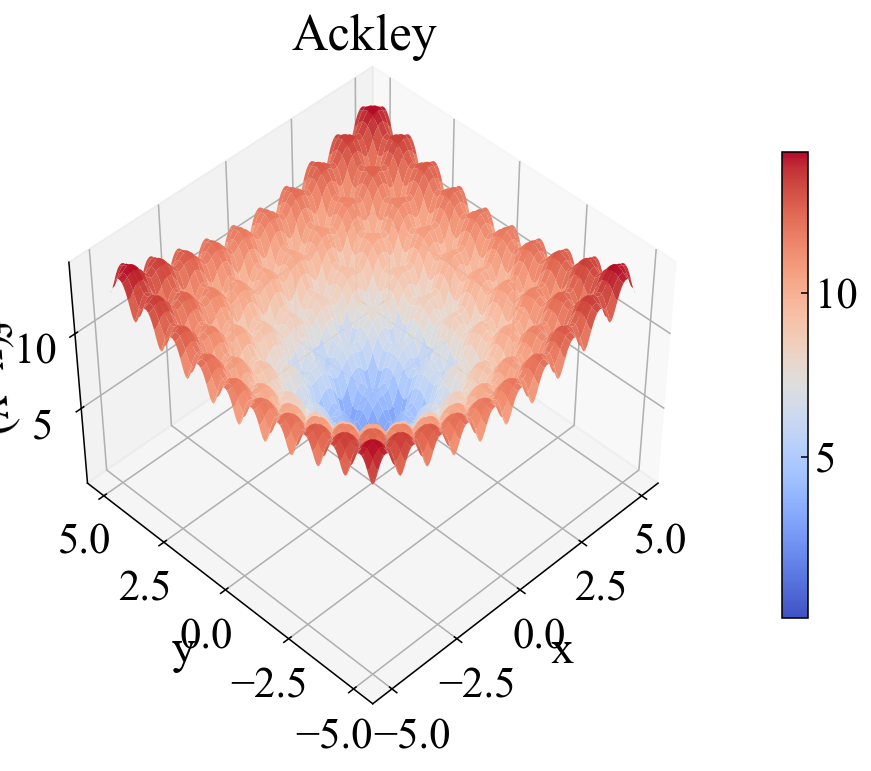

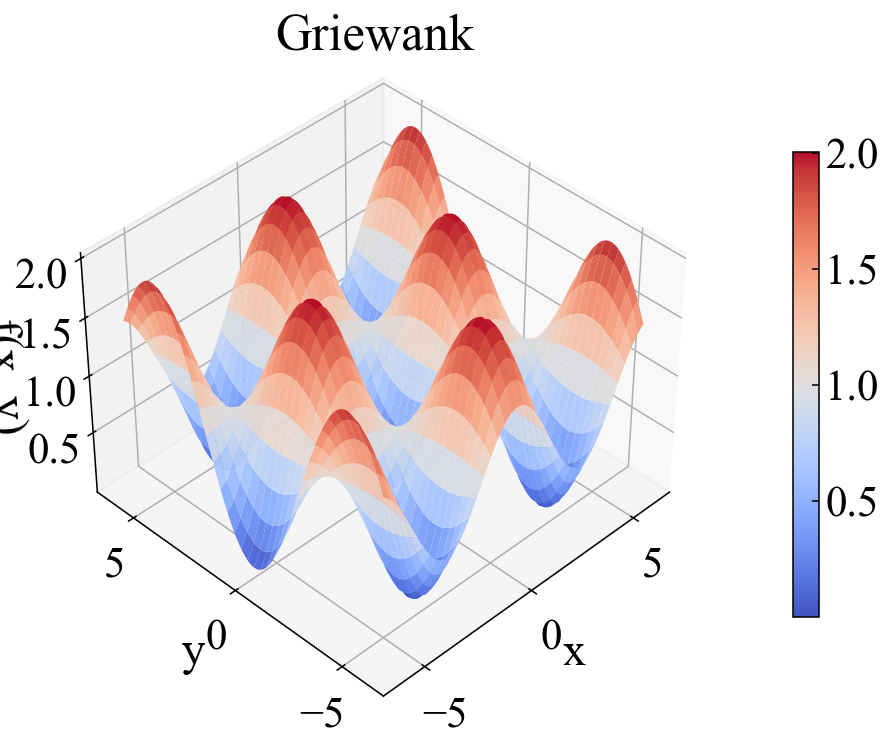

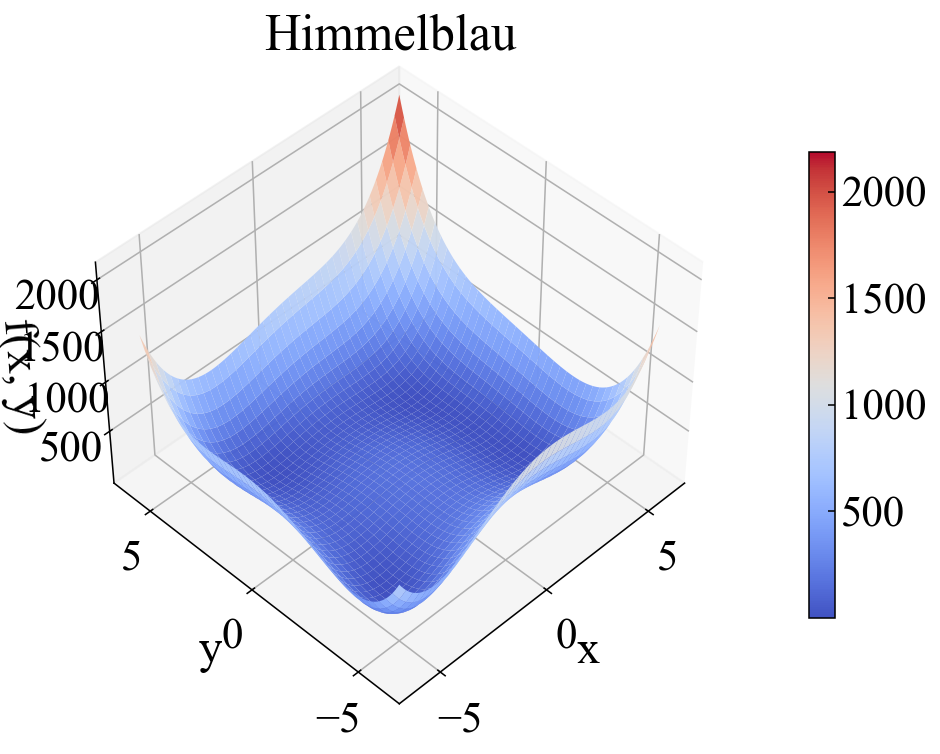

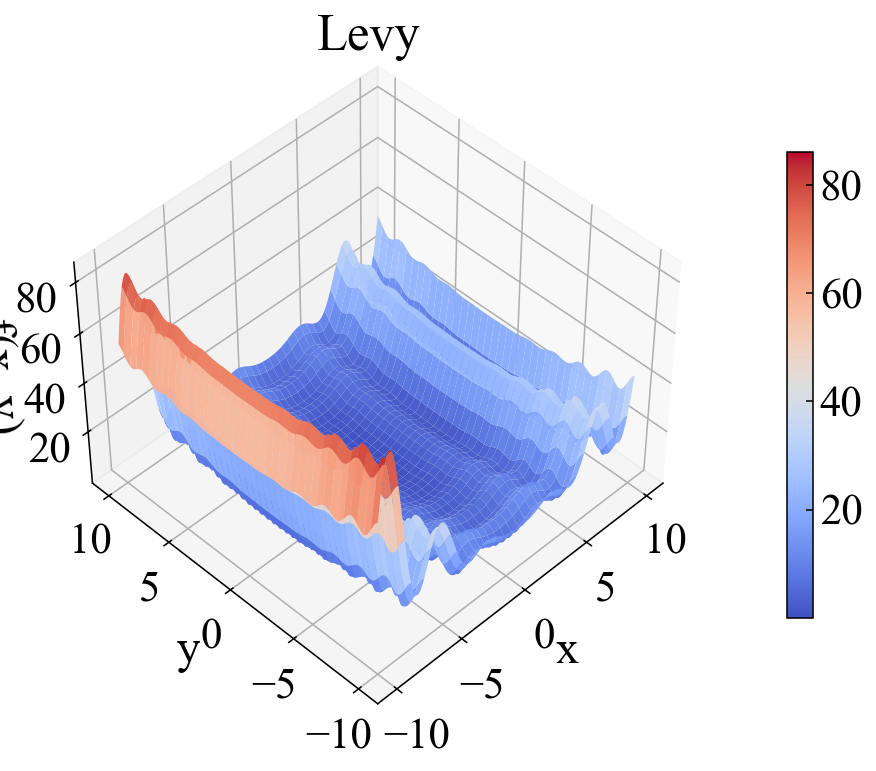

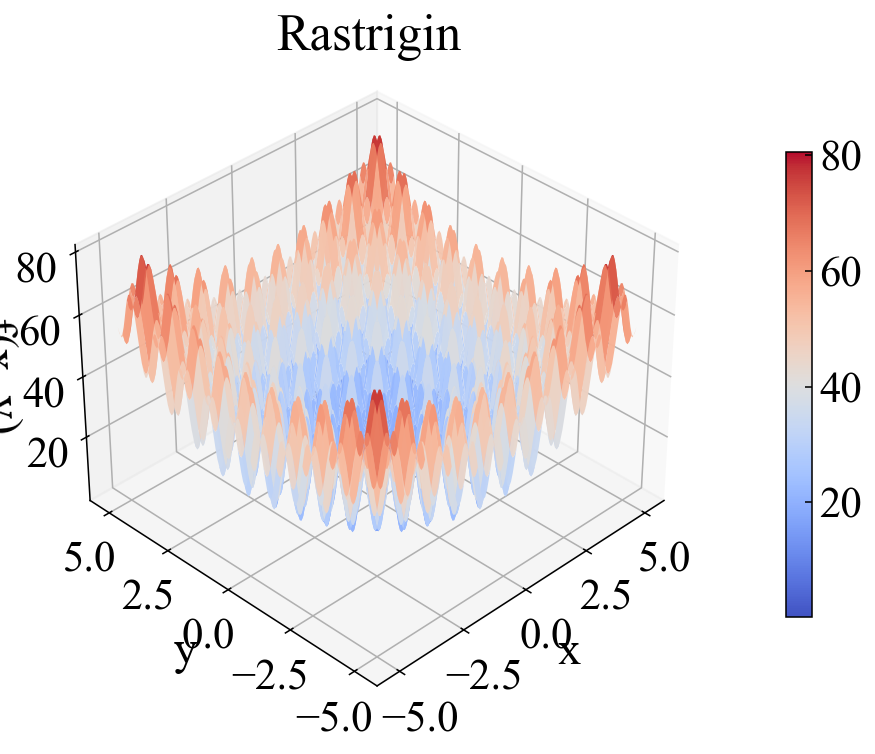

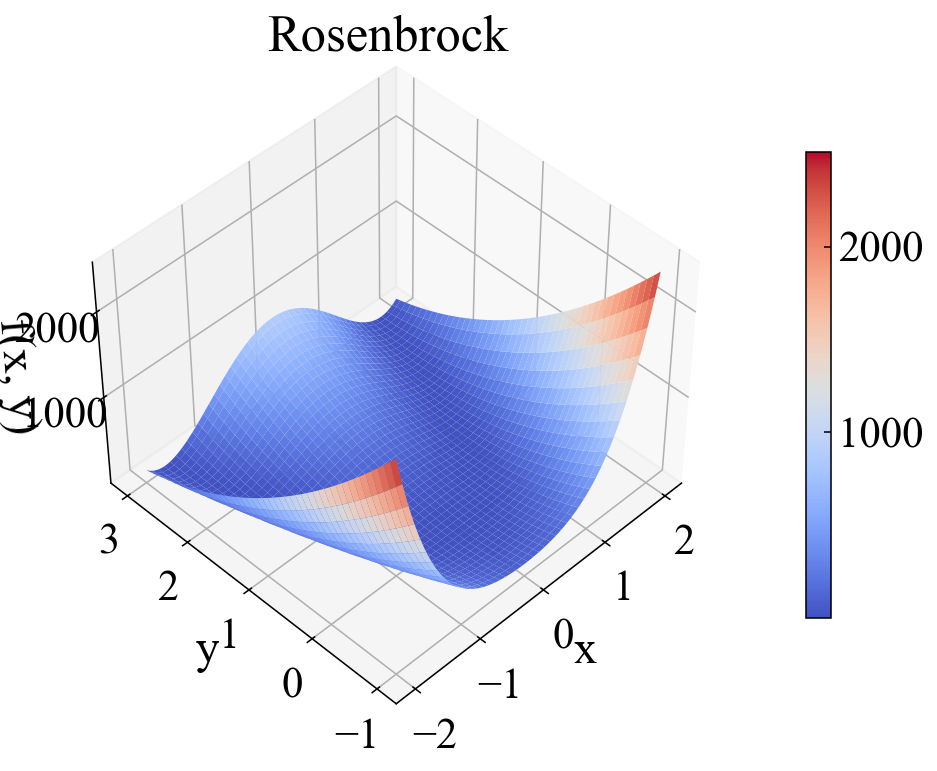

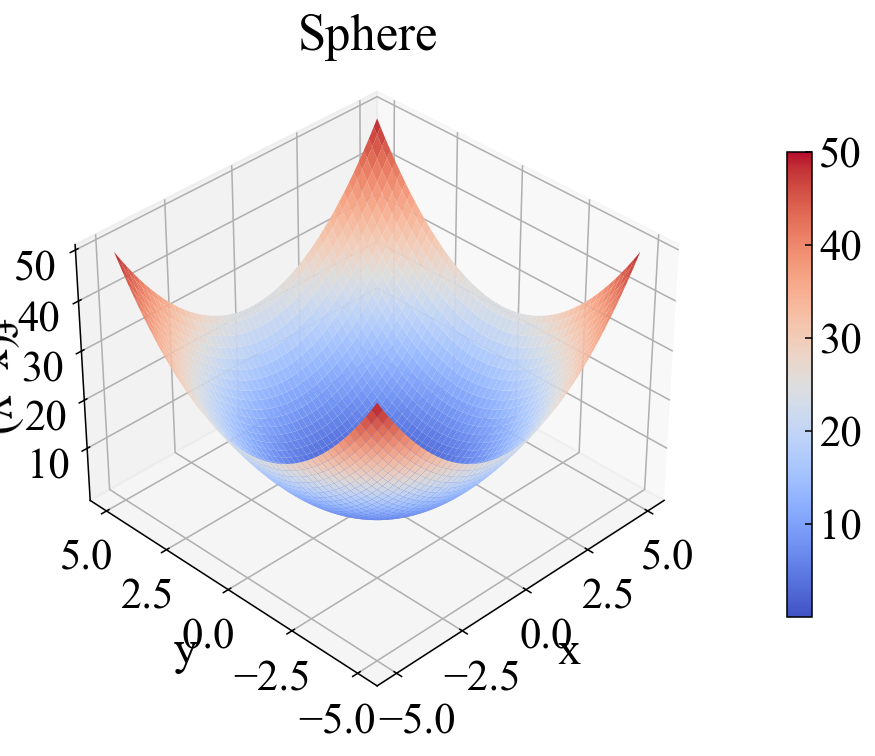

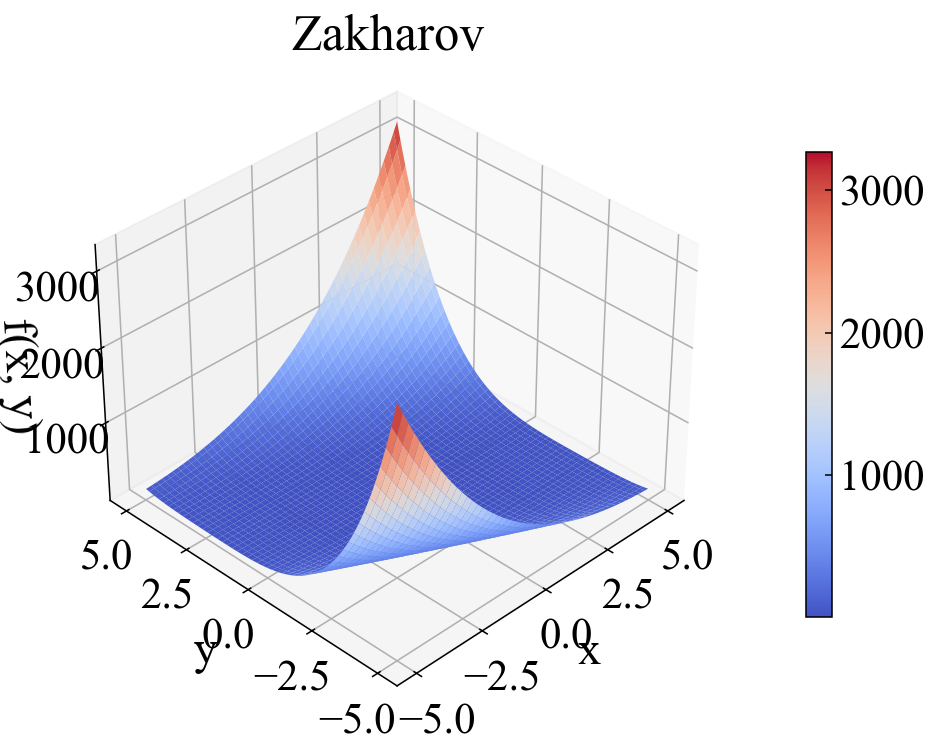

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 26,
})

COLORMAP = "coolwarm"
ANTI_ALIAS = True
DECIMATE_TARGET = 200

def f_ackley(X, Y):
    a, b, c = 20, 0.2, 2 * np.pi
    return (
        -a * np.exp(-b * np.sqrt((X**2 + Y**2) / 2.0))
        - np.exp((np.cos(c * X) + np.cos(c * Y)) / 2.0)
        + a + np.e
    )

def f_griewank(X, Y):
    return (X**2 + Y**2) / 4000.0 - np.cos(X) * np.cos(Y / np.sqrt(2)) + 1

def f_himmelblau(X, Y):
    return (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

def f_levy(X, Y):
    w1 = 1 + (X - 1) / 4.0
    w2 = 1 + (Y - 1) / 4.0
    return (
        (np.sin(np.pi * w1))**2
        + (w1 - 1)**2 * (1 + 10 * (np.sin(np.pi * w1 + np.pi))**2)
        + (w2 - 1)**2 * (1 + (np.sin(2 * np.pi * w2))**2)
    )

def f_rastrigin(X, Y):
    return 20 + (X**2 - 10 * np.cos(2 * np.pi * X)) + (Y**2 - 10 * np.cos(2 * np.pi * Y))

def f_rosenbrock(X, Y):
    return 100.0 * (Y - X**2)**2 + (1 - X)**2

def f_sphere(X, Y):
    return X**2 + Y**2

def f_zakharov(X, Y):
    s1 = X**2 + Y**2
    s2 = 0.5 * X + 1.0 * Y
    return s1 + s2**2 + s2**4

FUNC_MAP = {
    "Ackley": f_ackley,
    "Griewank": f_griewank,
    "Himmelblau": f_himmelblau,
    "Levy": f_levy,
    "Rastrigin": f_rastrigin,
    "Rosenbrock": f_rosenbrock,
    "Sphere": f_sphere,
    "Zakharov": f_zakharov,
}

BASE_GRID = {
    "Ackley": {"xlim": (-5, 5), "ylim": (-5, 5), "n": 300, "elev": 45, "azim": -135},
    "Griewank": {"xlim": (-6, 6), "ylim": (-6, 6), "n": 320, "elev": 40, "azim": -135},
    "Himmelblau": {"xlim": (-6, 6), "ylim": (-6, 6), "n": 320, "elev": 45, "azim": -135},
    "Levy": {"xlim": (-10, 10), "ylim": (-10, 10), "n": 320, "elev": 45, "azim": -135},
    "Rastrigin": {"xlim": (-5.12, 5.12), "ylim": (-5.12, 5.12), "n": 320, "elev": 35, "azim": -135},
    "Rosenbrock": {"xlim": (-2, 2), "ylim": (-1, 3), "n": 360, "elev": 45, "azim": -135},
    "Sphere": {"xlim": (-5, 5), "ylim": (-5, 5), "n": 300, "elev": 35, "azim": -135},
    "Zakharov": {"xlim": (-5, 5), "ylim": (-5, 5), "n": 300, "elev": 35, "azim": -135},
}

def decimate_mesh(XX, YY, ZZ, target_side=120):
    r = max(1, int(round(XX.shape[0] / target_side)))
    c = max(1, int(round(XX.shape[1] / target_side)))
    return XX[::r, ::c], YY[::r, ::c], ZZ[::r, ::c]

def plot_one(name, func, cfg):
    n = int(cfg["n"])
    xlo, xhi = cfg["xlim"]
    ylo, yhi = cfg["ylim"]
    X = np.linspace(xlo, xhi, n)
    Y = np.linspace(ylo, yhi, n)
    XX, YY = np.meshgrid(X, Y)
    ZZ = func(XX, YY)

    XXp, YYp, ZZp = decimate_mesh(XX, YY, ZZ, target_side=DECIMATE_TARGET)

    fig = plt.figure(figsize=(9.0, 5.5), dpi=140)
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(
        XXp, YYp, ZZp,
        linewidth=0,
        edgecolor="none",
        antialiased=ANTI_ALIAS,
        alpha=0.97,
        cmap=COLORMAP,
    )

    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")
    ax.tick_params(axis="both", which="major", direction="in", length=8)
    ax.tick_params(axis="both", which="minor", direction="in", length=4)
    ax.view_init(elev=cfg["elev"], azim=cfg["azim"])

    vmin, vmax = float(np.nanmin(ZZ)), float(np.nanmax(ZZ))
    surf.set_clim(vmin=vmin, vmax=vmax)
    cb = fig.colorbar(surf, ax=ax, shrink=0.72, aspect=18, pad=0.08)
    cb.ax.tick_params(direction="in")

    fig.tight_layout()

def main():
    for name in [
        "Ackley",
        "Griewank",
        "Himmelblau",
        "Levy",
        "Rastrigin",
        "Rosenbrock",
        "Sphere",
        "Zakharov"
    ]:
        plot_one(name, FUNC_MAP[name], BASE_GRID[name])
    plt.show()

if __name__ == "__main__":
    main()